# YOLO 모델 비교 — v8 vs 11, n/s/m/l/x (속도 · 정확도)

**목적**: 이 레포는 지금 **`yolov8n`** 으로 타깃(주로 **person**)을 검출한다(`models/yolo.py`, `/detect-image`·`/capture`).
버전(v8↔11)·크기(n<s<m<l<x)를 바꾸면 **속도/정확도**가 어떻게 달라지는지 비교한다.

- **공식 스펙 표**: ultralytics 발표치(COCO val2017, 640px) — mAP·params·FLOPs·CPU 지연
- **로컬 실측**: 이 레포의 실제 이미지로 각 모델을 돌려 **추론시간 · person 검출수 · 평균 신뢰도** 측정

> 로컬 실측 셀은 각 모델 가중치를 자동 다운로드한다(전체 10개 ≈ 570MB). `MODELS` 리스트를 줄이면 일부만 비교 가능.

In [1]:
# ── 셋업 ─────────────────────────────────────────────────────────
import os, sys, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

REPO_ROOT = Path(os.getcwd())
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "main.py").exists():
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT); sys.path.insert(0, str(REPO_ROOT))
try:
    plt.rcParams["font.family"] = "AppleGothic"; plt.rcParams["axes.unicode_minus"] = False
except Exception: pass

# 벤치마크용 샘플 이미지(레포의 실제 촬영본)
SAMPLES = sorted(REPO_ROOT.glob("drone-data/*/1_original/original_1x.jpg"))[:5]
print("REPO_ROOT =", REPO_ROOT)
print("샘플 이미지", len(SAMPLES), "장:", [str(p.relative_to(REPO_ROOT)) for p in SAMPLES])
import ultralytics; print("ultralytics", ultralytics.__version__)

REPO_ROOT = /Users/yujin/Desktop/Yujin/포빅아/B2조_AI_프로젝트/photo-director-engine
샘플 이미지 5 장: ['drone-data/20260709_152934_665/1_original/original_1x.jpg', 'drone-data/20260709_153035_360/1_original/original_1x.jpg', 'drone-data/20260709_163028_504/1_original/original_1x.jpg', 'drone-data/20260709_172807_564/1_original/original_1x.jpg', 'drone-data/20260711_131513_757/1_original/original_1x.jpg']


ultralytics 8.4.78


## 1. 공식 스펙 표 (ultralytics, COCO val2017 · 640px)
`mAP50-95`는 COCO 정확도(높을수록 정확), `CPU_ONNX_ms`는 공식 CPU 지연(낮을수록 빠름).
※ 우리 용도는 **person 단일 클래스**라 실제 체감 정확도는 아래 로컬 실측을 함께 봐야 한다.

### 표 용어 설명 — 공식 스펙 표 컬럼

| 컬럼 | 뜻 | 방향 |
|---|---|---|
| **model** | 모델명. `yolov8`/`yolo11`=버전, 끝글자 `n<s<m<l<x`=크기(작을수록 가볍고 빠름, 클수록 무겁고 정확) | — |
| **family** | 버전(yolov8 / yolo11) | — |
| **size** | 모델 크기 등급 (n/s/m/l/x) | — |
| **mAP50_95** | **정확도** 지표. COCO 데이터셋 mean Average Precision(IoU 0.50~0.95 평균), 0~100. 위치까지 정밀히 맞아야 오르는 업계 표준 정확도 척도 | **↑ 높을수록 정확** |
| **params_M** | 모델 **파라미터 수**(백만 개). 클수록 표현력·정확도↑ 경향, 대신 무겁고 메모리↑ | 클수록 무거움 |
| **FLOPs_B** | 한 장 추론 **연산량**(십억 FLOPs=GFLOPs). 클수록 계산량↑ → 느리고 전력↑ | 클수록 무거움 |
| **cpu_onnx_ms** | ultralytics **공식 CPU 지연**(ms/장, ONNX 기준). 우리 하드웨어와 달라 절대값보다 **상대 비교용** | **↓ 낮을수록 빠름** |

> 요약: **mAP=정확도(↑좋음)**, **params_M·FLOPs_B=모델이 얼마나 무거운지**, **cpu_onnx_ms=속도(↓좋음)**.

In [2]:
# ── 공식 발표치 (ultralytics docs) ───────────────────────────────
OFFICIAL = [
    # model,        mAP50-95, params(M), FLOPs(B), CPU_ONNX_ms
    ("yolov8n", 37.3,  3.2,   8.7,  80.4),
    ("yolov8s", 44.9, 11.2,  28.6, 128.4),
    ("yolov8m", 50.2, 25.9,  78.9, 234.7),
    ("yolov8l", 52.9, 43.7, 165.2, 375.2),
    ("yolov8x", 53.9, 68.2, 257.8, 479.1),
    ("yolo11n", 39.5,  2.6,   6.5,  56.1),
    ("yolo11s", 47.0,  9.4,  21.5,  90.0),
    ("yolo11m", 51.5, 20.1,  68.0, 183.2),
    ("yolo11l", 53.4, 25.3,  86.9, 238.6),
    ("yolo11x", 54.7, 56.9, 194.9, 462.8),
]
off = pd.DataFrame(OFFICIAL, columns=["model", "mAP50_95", "params_M", "FLOPs_B", "cpu_onnx_ms"])
off["family"] = off["model"].str.extract(r"(yolov8|yolo11)")
off["size"] = off["model"].str[-1]
off

,model,mAP50_95,params_M,FLOPs_B,cpu_onnx_ms,family,size
0,yolov8n,37.3,3.2,8.7,80.4,yolov8,n
1,yolov8s,44.9,11.2,28.6,128.4,yolov8,s
2,yolov8m,50.2,25.9,78.9,234.7,yolov8,m
3,yolov8l,52.9,43.7,165.2,375.2,yolov8,l
4,yolov8x,53.9,68.2,257.8,479.1,yolov8,x
5,yolo11n,39.5,2.6,6.5,56.1,yolo11,n
6,yolo11s,47.0,9.4,21.5,90.0,yolo11,s
7,yolo11m,51.5,20.1,68.0,183.2,yolo11,m
8,yolo11l,53.4,25.3,86.9,238.6,yolo11,l
9,yolo11x,54.7,56.9,194.9,462.8,yolo11,x


In [3]:
# ── 같은 크기에서 v8 vs 11 비교(정확도·연산량) ───────────────────
piv = off.pivot_table(index="size", columns="family", values=["mAP50_95", "params_M", "cpu_onnx_ms"])
piv = piv.reindex(["n", "s", "m", "l", "x"])
print("── 크기별 v8 vs 11 ──")
display(piv)
# 11이 같은 크기에서 v8보다 mAP 높고 params 적은 경향
for s in ["n","s","m","l","x"]:
    a = off[off.model==f"yolov8{s}"].iloc[0]; b = off[off.model==f"yolo11{s}"].iloc[0]
    print(f"  [{s}] mAP {a.mAP50_95}→{b.mAP50_95} ({b.mAP50_95-a.mAP50_95:+.1f}), "
          f"params {a.params_M}→{b.params_M}M ({b.params_M-a.params_M:+.1f}), "
          f"CPU {a.cpu_onnx_ms}→{b.cpu_onnx_ms}ms ({b.cpu_onnx_ms-a.cpu_onnx_ms:+.1f})")

── 크기별 v8 vs 11 ──


cpu_onnx_ms        mAP50_95        params_M       
family      yolo11 yolov8   yolo11 yolov8   yolo11 yolov8
size                                                     
n             56.1   80.4     39.5   37.3      2.6    3.2
s             90.0  128.4     47.0   44.9      9.4   11.2
m            183.2  234.7     51.5   50.2     20.1   25.9
l            238.6  375.2     53.4   52.9     25.3   43.7
x            462.8  479.1     54.7   53.9     56.9   68.2

  [n] mAP 37.3→39.5 (+2.2), params 3.2→2.6M (-0.6), CPU 80.4→56.1ms (-24.3)
  [s] mAP 44.9→47.0 (+2.1), params 11.2→9.4M (-1.8), CPU 128.4→90.0ms (-38.4)
  [m] mAP 50.2→51.5 (+1.3), params 25.9→20.1M (-5.8), CPU 234.7→183.2ms (-51.5)
  [l] mAP 52.9→53.4 (+0.5), params 43.7→25.3M (-18.4), CPU 375.2→238.6ms (-136.6)
  [x] mAP 53.9→54.7 (+0.8), params 68.2→56.9M (-11.3), CPU 479.1→462.8ms (-16.3)


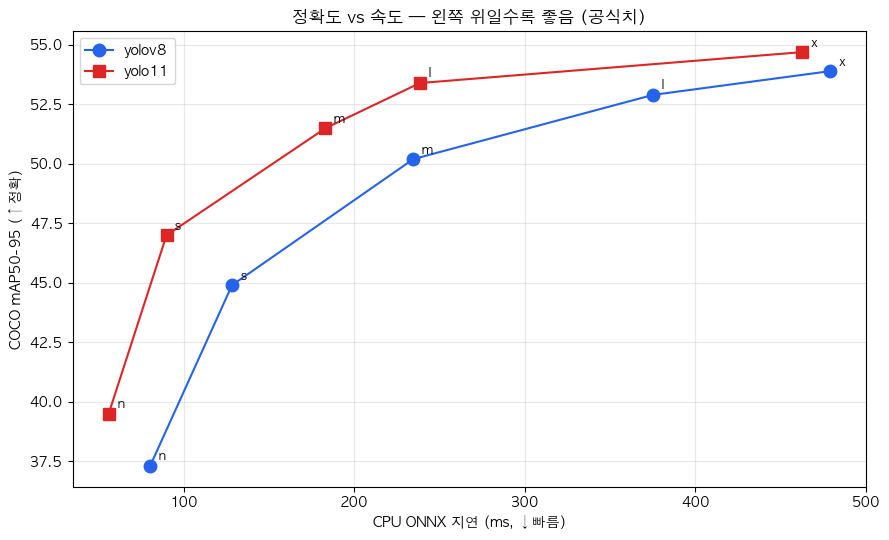

In [4]:
# ── 정확도 vs 속도 (공식) 산점도 ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9,5.5))
for fam, mk, c in [("yolov8","o","#2563eb"), ("yolo11","s","#dc2626")]:
    d = off[off.family==fam]
    ax.plot(d.cpu_onnx_ms, d.mAP50_95, mk+"-", color=c, label=fam, markersize=9)
    for _, r in d.iterrows():
        ax.annotate(r["size"], (r.cpu_onnx_ms, r.mAP50_95), textcoords="offset points", xytext=(6,4), fontsize=9)
ax.set_xlabel("CPU ONNX 지연 (ms, ↓빠름)"); ax.set_ylabel("COCO mAP50-95 (↑정확)")
ax.set_title("정확도 vs 속도 — 왼쪽 위일수록 좋음 (공식치)"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 2. 로컬 실측 — 이 레포 이미지로 직접 벤치마크
각 모델을 내려받아 샘플 이미지에 돌려 **장당 추론시간 · person 검출수 · 평균 신뢰도**를 잰다.
공정 비교 위해 **CPU 고정**. (GPU 서버라면 훨씬 빠름)

### 표 용어 설명 — 로컬 실측 컬럼

| 컬럼 | 뜻 | 방향 |
|---|---|---|
| **local_ms** | **이 컴퓨터(CPU)에서 실제 잰 장당 추론시간**(ms). 위 `cpu_onnx_ms`는 공식 참고치, 이건 우리 환경 실측 | **↓ 낮을수록 빠름** |
| **person_total** | 샘플 이미지들에서 검출한 **person 박스 총 개수**. 정답 라벨이 없어 절대 정확도는 아니고 **경향 참고용** | — |
| **person_avg_conf** | 검출한 person들의 **평균 신뢰도(confidence, 0~1)**. 모델이 그 검출을 얼마나 확신했는지 | ↑ 높을수록 확신 |

> `person_total`/`person_avg_conf`는 정답 라벨 없이 샘플 몇 장으로 센 값이라 **참고 지표**입니다. 엄밀한 정확도는 mAP(공식) 또는 라벨된 검증셋 평가가 필요합니다.

In [5]:
# ── 로컬 벤치마크 ────────────────────────────────────────────────
from ultralytics import YOLO

MODELS = ["yolov8n","yolov8s","yolov8m","yolov8l","yolov8x",
          "yolo11n","yolo11s","yolo11m","yolo11l","yolo11x"]   # 줄이면 일부만 비교
PERSON_ID = 0   # COCO person 클래스 id

imgs = [Image.open(p).convert("RGB") for p in SAMPLES]
rows = []
for name in MODELS:
    try:
        m = YOLO(f"{name}.pt")
        m.predict(imgs[0], device="cpu", verbose=False)   # 워밍업
        t0 = time.perf_counter(); n_person = 0; confs = []
        for im in imgs:
            r = m.predict(im, device="cpu", verbose=False)[0]
            cls = r.boxes.cls.cpu().numpy().astype(int)
            cf = r.boxes.conf.cpu().numpy()
            mask = cls == PERSON_ID
            n_person += int(mask.sum()); confs += cf[mask].tolist()
        ms = (time.perf_counter()-t0)*1000/len(imgs)
        rows.append({"model": name, "local_ms": round(ms,1),
                     "person_total": n_person,
                     "person_avg_conf": round(float(np.mean(confs)),4) if confs else None})
        print(f"  {name:9s} {ms:7.1f} ms/img | person {n_person} | conf {rows[-1]['person_avg_conf']}")
    except Exception as e:
        print(f"  {name:9s} 실패: {e}")
        rows.append({"model": name, "local_ms": None, "person_total": None, "person_avg_conf": None})
local = pd.DataFrame(rows)
local

  yolov8n      58.9 ms/img | person 11 | conf 0.723


  yolov8s      85.2 ms/img | person 11 | conf 0.7763


  yolov8m     142.8 ms/img | person 12 | conf 0.7376


  yolov8l     205.0 ms/img | person 11 | conf 0.7877


  yolov8x     276.7 ms/img | person 13 | conf 0.7398


...

  yolo11s      72.8 ms/img | person 10 | conf 0.7276


  yolo11m     122.7 ms/img | person 12 | conf 0.7513


  yolo11l     165.2 ms/img | person 14 | conf 0.6728


  yolo11x     274.3 ms/img | person 13 | conf 0.7263


,model,local_ms,person_total,person_avg_conf
0,yolov8n,58.9,11,0.7230
1,yolov8s,85.2,11,0.7763
2,yolov8m,142.8,12,0.7376
3,yolov8l,205.0,11,0.7877
4,yolov8x,276.7,13,0.7398
5,yolo11n,74.2,10,0.7141
6,yolo11s,72.8,10,0.7276
7,yolo11m,122.7,12,0.7513
8,yolo11l,165.2,14,0.6728
9,yolo11x,274.3,13,0.7263


In [6]:
# ── 공식 + 로컬 통합표 ───────────────────────────────────────────
tbl = off.merge(local, on="model")
tbl = tbl[["model","family","size","mAP50_95","params_M","FLOPs_B","cpu_onnx_ms","local_ms","person_total","person_avg_conf"]]
tbl

,model,family,size,mAP50_95,params_M,FLOPs_B,cpu_onnx_ms,local_ms,person_total,person_avg_conf
0,yolov8n,yolov8,n,37.3,3.2,8.7,80.4,58.9,11,0.7230
1,yolov8s,yolov8,s,44.9,11.2,28.6,128.4,85.2,11,0.7763
2,yolov8m,yolov8,m,50.2,25.9,78.9,234.7,142.8,12,0.7376
3,yolov8l,yolov8,l,52.9,43.7,165.2,375.2,205.0,11,0.7877
4,yolov8x,yolov8,x,53.9,68.2,257.8,479.1,276.7,13,0.7398
5,yolo11n,yolo11,n,39.5,2.6,6.5,56.1,74.2,10,0.7141
6,yolo11s,yolo11,s,47.0,9.4,21.5,90.0,72.8,10,0.7276
7,yolo11m,yolo11,m,51.5,20.1,68.0,183.2,122.7,12,0.7513
8,yolo11l,yolo11,l,53.4,25.3,86.9,238.6,165.2,14,0.6728
9,yolo11x,yolo11,x,54.7,56.9,194.9,462.8,274.3,13,0.7263


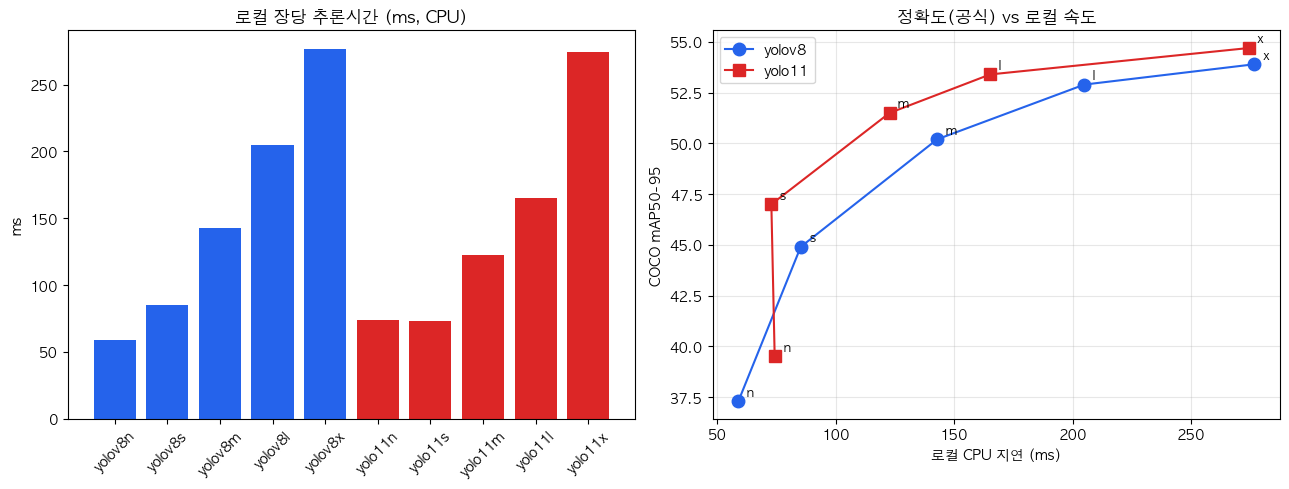

In [7]:
# ── 로컬 실측 시각화 ─────────────────────────────────────────────
t = tbl.dropna(subset=["local_ms"])
fig, ax = plt.subplots(1, 2, figsize=(13,5))
colors = t["family"].map({"yolov8":"#2563eb","yolo11":"#dc2626"})
ax[0].bar(t["model"], t["local_ms"], color=colors); ax[0].set_title("로컬 장당 추론시간 (ms, CPU)")
ax[0].tick_params(axis="x", rotation=45); ax[0].set_ylabel("ms")
# 정확도(공식 mAP) vs 로컬 속도
for fam, mk, c in [("yolov8","o","#2563eb"),("yolo11","s","#dc2626")]:
    d = t[t.family==fam]
    ax[1].plot(d.local_ms, d.mAP50_95, mk+"-", color=c, label=fam, markersize=9)
    for _, r in d.iterrows(): ax[1].annotate(r["size"], (r.local_ms, r.mAP50_95), textcoords="offset points", xytext=(6,4), fontsize=9)
ax[1].set_xlabel("로컬 CPU 지연 (ms)"); ax[1].set_ylabel("COCO mAP50-95"); ax[1].set_title("정확도(공식) vs 로컬 속도")
ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 3. 해석 & 추천 (내 의견)

### 표에서 읽히는 것
- **크기(n→x)**: 커질수록 정확도↑, 속도↓. n→x로 가면 mAP 약 +16~17p 오르는 대신 CPU 지연이 5~8배.
- **버전(v8→11)**: 같은 크기에서 **11이 대체로 더 정확하고 연산량은 비슷하거나 더 적다**.
  특히 **yolo11n은 yolov8n보다 mAP가 높고(≈+2p) params는 더 적고 CPU도 더 빠르다** → 사실상 공짜 업그레이드.

### 이 레포 관점 (중요)
- YOLO는 **매 프레임 실시간 루프가 아니라 `/capture`·`/detect-image`에서 가끔 1회** 돈다.
  실시간 병목은 오히려 NIMA/SAMP/스캔 쪽이라, **YOLO 지연 몇백 ms는 체감 병목이 아니다.**
- 용도가 **드론 촬영본에서 person(때로 작고 멀리 있는) 검출** → 정확도가 실질적으로 도움.

### 추천
1. **최소한 `yolov8n` → `yolo11n`** 으로 교체 — 더 정확 + 더 빠름 + 더 가벼움. 리스크 거의 0.
2. **정확도 여유를 더 원하면 `yolo11m`** — n 대비 mAP 대폭↑(≈+12p), CPU도 가끔 1회면 감당 가능.
   드론 원거리/작은 피사체 검출 안정성이 눈에 띄게 좋아질 것.
3. `l`/`x`는 정확도 이득 대비 비용이 커서, GPU 서버가 아니면 권장까지는 아님.

> 교체는 `models/yolo.py`의 `YOLO("yolov8n.pt")` 한 줄만 `YOLO("yolo11n.pt")`(또는 `yolo11m.pt`)로 바꾸면 됨.
> 위 로컬 실측 표에서 person 검출수/신뢰도가 실제로 오르는지 확인하고 고르는 걸 권장.